# Datalab 2

## groep 6 : 
- Ardjun Debi - Tewarie (25032895)
- Azfar Mohab Ali (25026356)
- Tesja Kartomo (25035193)
- Shelby Gibbs (18005055)
# [HERKANSINGEN]
- [Sprint 3 visualisaties (scatterplots)](#visualisaties-van-teameigenschappen-en-punten) - Feedback van de herkansing hiervan: er zijn geen visualisaties voor class variabelen. Er is maar 1 scatterplot
- [Sprint 3 aantal wedstrijden per seizoen (kalenderjaar 2010)](#1B:-Aantal-wedstrijden-in-het-kalenderjaar-2010-per-seizoen) - we haden matig (0.5 punten) omdat de berekening onvolledig was. we hebben aangepast en de query correct uitgevoerd zodat het de aantal wedstrijden toont per seizoen in het kalenderjar van 2010

## Import en connectie met de database

Hier maken we gebruik van een `DatabaseViewer` class die de verbinding met de database (`./assets/database.sqlite`) opzet en functies bevat om SQL queries uit te voeren en zowel volledige resultaten als een preview (eerste rij) weer te geven.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class DatabaseViewer:
    """
    Klasse voor het verbinden met en bekijken van data uit een SQLite database.

    Attributes
    ----------
    db_path : str
        Pad naar de database.
    conn : sqlite3.Connection
        Actieve databaseverbinding.
    """

    def __init__(self, db_path="./assets/database.sqlite"):
        """
        Initialiseert de databaseverbinding.

        Parameters
        ----------
        db_path : str, optional
            Pad naar de SQLite database (standaard './assets/database.sqlite').
        """
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path)
        print(f"Database connectie is gemaakt met: {db_path}")

    def show_query(self, query):
        """
        Voert een SQL-query uit.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        DataFrame
            Toont het resultaat als pandas DataFrame.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df)
        return df

    def show_head_query(self, query):
        """
        Voert een SQL-query uit en toont de eerste rij.

        Parameters
        ----------
        query : str
            De SQL-query die uitgevoerd moet worden.

        Returns
        -------
        Eerste rij dataframe
            Toont alleen de eerste rij van het resultaat.
        """
        df = pd.read_sql_query(query, self.conn)
        display(df.head(1))


bar = DatabaseViewer()


Database connectie is gemaakt met: ./assets/database.sqlite


## Stap 1: team_api_id van Barcelona vinden

- **Stap 1:** Zoek in de tabel **Team** naar de `team_api_id` van **FC Barcelona**. Deze identifier gebruiken we later om wedstrijden van dit team te vinden.

In [2]:
# stap 1: vind de team_api_id van FC Barcelona
bar.show_query("""
SELECT team_long_name, team_api_id
FROM Team
WHERE team_long_name = 'FC Barcelona';
""")


,team_long_name,team_api_id
0,FC Barcelona,8634


,team_long_name,team_api_id
0,FC Barcelona,8634


## Stap 2: Matches van Barcelona vinden

- **Stap 2:** Zoekt naar wedstrijden waarin Barcelona speelt door `team_api_id` (8634) in de tabel **Match** te filteren. Hierbij kijken we zowel naar `home_team_api_id` als `away_team_api_id`.

In [3]:
# stap 2: vind de matches door middel van team_api_id van barcelona
bar.show_query("""
SELECT
  Match.id,
  Match.season,
  Match.country_id,
  Match.league_id,
  Match.home_team_api_id,
  Match.away_team_api_id
FROM Match
WHERE Match.home_team_api_id = 8634
   OR Match.away_team_api_id = 8634
LIMIT 5;
          
""")

,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


,id,season,country_id,league_id,home_team_api_id,away_team_api_id
0,21521,2008/2009,21518,21518,8388,8634
1,21535,2008/2009,21518,21518,8634,10281
2,21547,2008/2009,21518,21518,8479,8634
3,21550,2008/2009,21518,21518,8634,8305
4,21564,2008/2009,21518,21518,8302,8634


## Stap 3: League van Barcelona bepalen

- **Stap 3.1:** Zoek de `league_id` van een wedstrijd waarin Barcelona speelt.  
- **Stap 3.2:** Zoek de `country_id` van deze wedstrijd.  
- **Stap 3.3:** Gebruik de `country_id` om de naam van de **League** te vinden.

In [4]:
# stap 3: vind de league_id's en de naam van de league van de matches van barcelona
# stap 3.1: vind de league id
bar.show_query(
"""
SELECT Match.league_id
FROM Match
WHERE Match.home_team_api_id = 8634 OR Match.away_team_api_id = 8634
LIMIT 1;
""")

# stap 3.2: vind eerste de country id om makkelijjker te zoeken naar de name van de League
bar.show_query(
"""
SELECT Match.country_id
FROM Match
WHERE home_team_api_id = 8634
LIMIT 1
"""
)
# stap 3.3 vind nu de naam van de league:
bar.show_query(
"""
SELECT League.Name
FROM League
WHERE country_id = 21518
LIMIT 1
"""
)



,league_id
0,21518


,country_id
0,21518


,name
0,Spain LIGA BBVA


,name
0,Spain LIGA BBVA


## Belangrijke variablen
- Team : **Barcelona**
- `Team_api_id`, `home_team_api_id`, `away_team_api_id` : 8634
- `Country_id`, `League_id` : 21518
- `League.Name` : Spain LIGA BBVA

## Relaties:
### Tabel met relaties:
| Kolom| Van tabel | Naar tabel | Naar kolom | Beschrijving|
| ------------------ | ----------------- | ---------- | ------------------ | ----------------------------------------------------------------------- |
| country_id | League| Country| id | Geeft aan in welk land de **competitie plaatsvindt**. |
| country_id | Match | Country| id | Geeft aan in welk land de **wedstrijd gespeeld** wordt. |
| league_id| Match | League | id | **Verbindt** een wedstrijd aan de competitie waarin deze gespeeld wordt.|
| home_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **thuiswedstrijd** speelt.|
| away_team_api_id | Match | Team | team_api_id| Verwijst naar het team dat de **uitwedstrijd** speelt.|
| player_api_id| Player_Attributes | Player | player_api_id| **Verbindt** de spelers attributen met een specifieke speler.|
| player_fifa_api_id | Player_Attributes | Player | player_fifa_api_id | Alternatieve identifier uit FIFA dat die attributen aan een speler **koppelt**. |
| team_api_id| Team_Attributes | Team | team_api_id| **Verbindt** team attributen met een specifiek team. |
| team_fifa_api_id | Team_Attributes | Team | team_fifa_api_id | FIFA identifier die team attributen **koppelt** aan een team.|
| away_player_1| Match | Player | player_api_id| Eerste speler van het **uit team** in de wedstrijd. |
| away_player_2| Match | Player | player_api_id| Tweede speler van het **uit team** in de wedstrijd. |
| away_player_3| Match | Player | player_api_id| Derde speler van het **uit team** in de wedstrijd.|
| away_player_4| Match | Player | player_api_id| Vierde speler van het **uit team** in de wedstrijd. |
| away_player_5| Match | Player | player_api_id| Vijfde speler van het **uit team** in de wedstrijd. |
| away_player_6| Match | Player | player_api_id| Zesde speler van het **uit team** in de wedstrijd.|
| away_player_7| Match | Player | player_api_id| Zevende speler van het **uit team** in de wedstrijd.|
| away_player_8| Match | Player | player_api_id| Achtste speler van het **uit team** in de wedstrijd.|
| away_player_9| Match | Player | player_api_id| Negende speler van het **uit team** in de wedstrijd.|
| away_player_10 | Match | Player | player_api_id| Tiende speler van het **uit team** in de wedstrijd. |
| away_player_11 | Match | Player | player_api_id| Elfde speler van het **uit team** in de wedstrijd.|
| home_player_1| Match | Player | player_api_id| Eerste speler van het **thuis team** in de wedstrijd. |
| home_player_2| Match | Player | player_api_id| Tweede speler van het **thuis team** in de wedstrijd. |
| home_player_3| Match | Player | player_api_id| Derde speler van het **thuis team** in de wedstrijd.|
| home_player_4| Match | Player | player_api_id| Vierde speler van het **thuis team** in de wedstrijd. |
| home_player_5| Match | Player | player_api_id| Vijfde speler van het **thuis team** in de wedstrijd. |
| home_player_6| Match | Player | player_api_id| Zesde speler van het **thuis team** in de wedstrijd.|
| home_player_7| Match | Player | player_api_id| Zevende speler van het **thuis team** in de wedstrijd.|
| home_player_8| Match | Player | player_api_id| Achtste speler van het **thuis team** in de wedstrijd.|
| home_player_9| Match | Player | player_api_id| Negende speler van het **thuis team** in de wedstrijd.|
| home_player_10 | Match | Player | player_api_id| Tiende speler van het **thuis team** in de wedstrijd. |
| home_player_11 | Match | Player | player_api_id| Elfde speler van het **thuis team** in de wedstrijd.|

### Samengevat:
Elke wedstrijd is gekoppeld aan een competitie via `league_id` en aan twee teams via `home_team_api_id` en `away_team_api_id`, die verwijzen naar de tabel **Team**.

De spelers die in een wedstrijd spelen staan in de kolommen `home_player_1` t/m `home_player_11` en `away_player_1` t/m `away_player_11`. Deze verwijzen naar de tabel **Player**.

De tabellen `Player_Attributes` en `Team_Attributes` bevatten extra informatie over **spelers** en **teams** en zijn gekoppeld via hun **API identifiers**.


## Ranglijst
Seizoen : 2015

In [5]:
bar.show_query(
"""
SELECT date
FROM match 
WHERE date LIKE "2015%"
""")

,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


,date
0,2015-02-03 00:00:00
1,2015-01-16 00:00:00
2,2015-01-18 00:00:00
3,2015-01-17 00:00:00
4,2015-01-17 00:00:00
...,...
3369,2015-09-22 00:00:00
3370,2015-09-23 00:00:00
3371,2015-09-23 00:00:00
3372,2015-09-22 00:00:00


In [6]:
# Ranglijst - La Liga seizoen 2015/2016
import sqlite3
import pandas as pd

# Verbinding maken met de database
conn = sqlite3.connect("./assets/database.sqlite")


def get_ranglijst(conn, league_id, seizoen):
    """
    Berekent de ranglijst van een competitie voor een gegeven seizoen.

    Parameters:
        conn       : sqlite3 verbinding met de database
        league_id  : int, de league_id van de competitie (bijv. 21518 voor La Liga)
        seizoen    : str, het seizoen als string (bijv. '2015/2016')

    Returns:
        pd.DataFrame met kolommen: Positie, Team, GS, W, G, V, DV, DT, DS, Punten
        gesorteerd op punten (desc), dan doelsaldo (desc), dan doelpunten voor (desc)
    """

    # Stap 1: Haal alle wedstrijden op uit het gekozen seizoen en competitie
    query = f"""
        SELECT
            m.home_team_api_id AS home_id,
            m.away_team_api_id AS away_id,
            m.home_team_goal   AS home_goal,
            m.away_team_goal   AS away_goal
        FROM Match m
        WHERE m.league_id = {league_id}
          AND m.season = '{seizoen}'
    """
    matches = pd.read_sql_query(query, conn)

    # Stap 2: Haal de teamnamen op zodat we ID's kunnen omzetten naar namen
    team_query = "SELECT team_api_id, team_long_name FROM Team"
    teams = pd.read_sql_query(team_query, conn)
    team_dict = dict(zip(teams['team_api_id'], teams['team_long_name']))

    # Stap 3: Maak een lege statistieken-dictionary aan voor elk uniek team
    alle_teams = set(matches['home_id']).union(set(matches['away_id']))
    stats = {t: {'GS': 0, 'W': 0, 'G': 0, 'V': 0, 'DV': 0, 'DT': 0} for t in alle_teams}

    # Stap 4: Loop door alle wedstrijden en bereken de statistieken per team
    for _, row in matches.iterrows():
        h, a   = row['home_id'],   row['away_id']
        hg, ag = row['home_goal'], row['away_goal']

        # Aantal gespeelde wedstrijden ophogen voor beide teams
        stats[h]['GS'] += 1
        stats[a]['GS'] += 1

        # Doelpunten bijhouden voor beide teams
        stats[h]['DV'] += hg
        stats[h]['DT'] += ag
        stats[a]['DV'] += ag
        stats[a]['DT'] += hg

        # Bepaal de uitslag winst/gelijk/verlies
        if hg > ag:        # Thuisploeg wint
            stats[h]['W'] += 1
            stats[a]['V'] += 1
        elif hg < ag:      # Uitploeg wint
            stats[a]['W'] += 1
            stats[h]['V'] += 1
        else:              # Gelijkspel
            stats[h]['G'] += 1
            stats[a]['G'] += 1

    # Stap 5: Zet de statistieken om naar een overzichtelijke lijst
    rijen = []
    for team_id, s in stats.items():
        punten = s['W'] * 3 + s['G']   # Winst = 3 punten, gelijk = 1 punt
        ds     = s['DV'] - s['DT']     # Doelsaldo = doelpunten voor - tegen

        rijen.append({
            'Team'   : team_dict.get(team_id, str(team_id)),
            'GS'     : s['GS'],
            'W'      : s['W'],
            'G'      : s['G'],
            'V'      : s['V'],
            'DV'     : s['DV'],
            'DT'     : s['DT'],
            'DS'     : ds,
            'Punten' : punten
        })

    # Stap 6: Maak een DataFrame en sorteer op punten, doelsaldo, doelpunten voor
    ranglijst = pd.DataFrame(rijen)
    ranglijst = ranglijst.sort_values(
        by=['Punten', 'DS', 'DV'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    # Positie begint bij 1 in plaats van 0
    ranglijst.index += 1
    ranglijst.index.name = 'Positie'

    return ranglijst


# Roep de functie aan voor La Liga seizoen 2015/2016
ranglijst_2015 = get_ranglijst(conn, league_id=21518, seizoen='2015/2016')
display(ranglijst_2015)

,Team,GS,W,G,V,DV,DT,DS,Punten
Positie,,,,,,,,,
1,FC Barcelona,38,29,4,5,112,29,83,91
2,Real Madrid CF,38,28,6,4,110,34,76,90
3,Atlético Madrid,38,28,4,6,63,18,45,88
4,Villarreal CF,38,18,10,10,44,35,9,64
5,Athletic Club de Bilbao,38,18,8,12,58,45,13,62
6,RC Celta de Vigo,38,17,9,12,51,59,-8,60
7,Sevilla FC,38,14,10,14,51,50,1,52
8,Málaga CF,38,12,12,14,38,35,3,48
9,Real Sociedad,38,13,9,16,45,48,-3,48


## Uitleg van de ranglijst

De ranglijst laat zien hoe alle clubs in La Liga het hebben gedaan in het seizoen 2015/2016. Hieronder leggen we uit wat elke kolom betekent:

- **Positie** – De plek van het team in de competitie, gebaseerd op het aantal punten.
- **Team** – De naam van de voetbalclub.
- **GS** – Gespeelde wedstrijden. Hoeveel wedstrijden het team heeft gespeeld dat seizoen.
- **W** – Gewonnen. Het aantal wedstrijden dat het team heeft gewonnen.
- **G** – Gelijk. Het aantal wedstrijden dat gelijkgespeeld is.
- **V** – Verloren. Het aantal wedstrijden dat het team heeft verloren.
- **DV** – Doelpunten Vóór. Het totaal aantal doelpunten dat het team zelf heeft gescoord.
- **DT** – Doelpunten Tégen. Het totaal aantal doelpunten dat het team heeft weggegeven.
- **DS** – Doelsaldo. Het verschil tussen DV en DT (DV - DT). Een positief getal betekent dat een team meer heeft gescoord dan weggegeven.
- **Punten** – Het totaal aantal punten. Een overwinning levert 3 punten op, een gelijkspel 1 punt en een verlies 0 punten. Bij een gelijk aantal punten wordt gekeken naar het doelsaldo.

------------------------------------------------------------------------------------------------------------------------

# SPRINT 3
## 1A: Aantal wedstrijden per seizoen
Hier hebben we met behulp van SQL het aantal wedstrijden per seizoen van FC Barcelona kunnen aan tonen.


Stap 1: Tel, met gebruik van `league_id`, `home_team_api_id` en `away_team_api_id`, de aantal wedstrijden per seizoen.

In [7]:
#Stap 1: Toon het aantal wedstrijden per seizoen
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE home_team_api_id = 8634 
   OR away_team_api_id = 8634
GROUP BY league.name, season;
"""
)

,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2008/2009,38
1,Spain LIGA BBVA,2009/2010,38
2,Spain LIGA BBVA,2010/2011,38
3,Spain LIGA BBVA,2011/2012,38
4,Spain LIGA BBVA,2012/2013,38
5,Spain LIGA BBVA,2013/2014,38
6,Spain LIGA BBVA,2014/2015,38
7,Spain LIGA BBVA,2015/2016,38


### 1B: Aantal wedstrijden in het kalenderjaar 2010 per seizoen


In [8]:
#Het aantal wedstrijden tonen per seizoen in het kalenderjaar 2010
bar.show_query(
"""
SELECT league.name, season, COUNT(*) AS aantal_wedstrijden
FROM match
INNER JOIN league ON match.league_id = league.id
WHERE (home_team_api_id = 8634 OR away_team_api_id = 8634)
  AND date >= '2010-01-01'
  AND date < '2011-01-01'
GROUP BY league.name, season;
"""
)

,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2009/2010,23
1,Spain LIGA BBVA,2010/2011,16


,name,season,aantal_wedstrijden
0,Spain LIGA BBVA,2009/2010,23
1,Spain LIGA BBVA,2010/2011,16


###  1C: Hoeveelheid punten ieder team had gehaald per seizoen 

In [9]:
#Stap 3: toon hoeveel punten ieder team in ons compititie gehaald heeft per seizoen
bar.show_query(
"""SELECT
    league.name AS league,
    season,
    team.team_long_name AS team,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN league ON match.league_id = league.id
INNER JOIN team ON team.team_api_id = match.home_team_api_id 
               OR team.team_api_id = match.away_team_api_id
WHERE league.name = 'Spain LIGA BBVA'
GROUP BY league.name, season, team.team_api_id
ORDER BY season, punten DESC;
"""
)

# case doet hier dus het volgende: als het team de thuisploeg is en wint, krijgt het 3 punten. Als het team de uitploeg is en wint, krijgt het ook 3 punten. Als er een gelijkspel is, krijgen beide teams 1 punt. In alle andere gevallen (verlies) krijgt het team 0 punten.



,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


,league,season,team,punten
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87
1,Spain LIGA BBVA,2008/2009,Real Madrid CF,78
2,Spain LIGA BBVA,2008/2009,Sevilla FC,70
3,Spain LIGA BBVA,2008/2009,Atlético Madrid,67
4,Spain LIGA BBVA,2008/2009,Villarreal CF,65
...,...,...,...,...
155,Spain LIGA BBVA,2015/2016,Granada CF,39
156,Spain LIGA BBVA,2015/2016,Real Sporting de Gijón,39
157,Spain LIGA BBVA,2015/2016,Rayo Vallecano,38
158,Spain LIGA BBVA,2015/2016,Getafe CF,36


### 1D: Rank tonen op ranglijst


In [10]:
#Stap 3: Toon op welke plaats Barcelona is geëindigd in de ranglijst competitie per seizoen

# WITH ranglijst AS (...) -> subquery dat eerst de volledige ranglijst met alle teams berekent.
# RANK() OVER (PARTITION BY season ...) -> geeft elke team een eindpositie per seizoen.
# Buitenste WHERE team = 'FC Barcelona' -> filtert pas daarna op Barca, zodat de positie correct is berekend op basis van alle teams.
# Het resultaat toont per seizoen hoeveel punten Barca had en op welke positie ze eindigden.
bar.show_query(
"""WITH ranglijst AS (
    SELECT
        league.name AS league,
        season,
        team.team_long_name AS team,
        SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) AS punten,
        RANK() OVER (PARTITION BY season ORDER BY SUM(
            CASE 
                WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
                WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
                WHEN home_team_goal = away_team_goal THEN 1
                ELSE 0 
            END
        ) DESC) AS positie
    FROM match
    INNER JOIN league ON match.league_id = league.id
    INNER JOIN team ON team.team_api_id = match.home_team_api_id 
                   OR team.team_api_id = match.away_team_api_id
    WHERE league.name = 'Spain LIGA BBVA'
    GROUP BY league.name, season, team.team_api_id
)
SELECT league, season, team, punten, positie
FROM ranglijst
WHERE team = 'FC Barcelona'
ORDER BY season;
"""
)




,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


,league,season,team,punten,positie
0,Spain LIGA BBVA,2008/2009,FC Barcelona,87,1
1,Spain LIGA BBVA,2009/2010,FC Barcelona,99,1
2,Spain LIGA BBVA,2010/2011,FC Barcelona,96,1
3,Spain LIGA BBVA,2011/2012,FC Barcelona,91,2
4,Spain LIGA BBVA,2012/2013,FC Barcelona,100,1
5,Spain LIGA BBVA,2013/2014,FC Barcelona,87,2
6,Spain LIGA BBVA,2014/2015,FC Barcelona,94,1
7,Spain LIGA BBVA,2015/2016,FC Barcelona,91,1


## stappen voor 2a

We hebben een dataframe met punten per team **samengevoegd** met teameigenschappen uit **Team_Attributes** op basis van **team_api_id**. Hierdoor hebben we één dataset voor verdere analyse.

**Teameigenschappen**:

- `buildUpPlaySpeed`
- `buildUpPlayDribbling`
- `buildUpPlayPassing`
- `chanceCreationPassing`
- `chanceCreationCrossing`
- `chanceCreationShooting`
- `defencePressure`
- `defenceAggression`
- `defenceTeamWidth`

In [11]:
punten_df = bar.show_query(
"""SELECT
    season,
    team.team_long_name AS team,
    team.team_api_id,
    SUM(
        CASE 
            WHEN match.home_team_api_id = team.team_api_id AND home_team_goal > away_team_goal THEN 3
            WHEN match.away_team_api_id = team.team_api_id AND away_team_goal > home_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0 
        END
    ) AS punten
FROM match
INNER JOIN team 
    ON team.team_api_id = match.home_team_api_id 
    OR team.team_api_id = match.away_team_api_id
GROUP BY match.season, team.team_long_name, team.team_api_id
ORDER BY match.season, punten DESC
"""
)


,season,team,team_api_id,punten
0,2008/2009,Manchester United,10260,90
1,2008/2009,FC Barcelona,8634,87
2,2008/2009,Liverpool,8650,86
3,2008/2009,Rangers,8548,86
4,2008/2009,Inter,8636,84
...,...,...,...,...
1476,2015/2016,Hannover 96,9904,25
1477,2015/2016,De Graafschap,8526,23
1478,2015/2016,ES Troyes AC,10242,18
1479,2015/2016,SC Cambuur,7788,18


In [12]:
# stap 2. Team attributes ophalen
teameig_df = bar.show_query("""
SELECT
    team_api_id,
    date,
    buildUpPlaySpeed,
    buildUpPlayDribbling,
    buildUpPlayPassing,
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,
    defencePressure,
    defenceAggression,
    defenceTeamWidth
FROM Team_Attributes
GROUP BY team_api_id""")

# stap 3. Samenvoegen 
samengevoegd_df = punten_df.merge(teameig_df, on="team_api_id")

display(samengevoegd_df.head(10))


,team_api_id,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,1601,2010-02-22 00:00:00,30,NaN,40,50,35,70,65,60,50
1,1773,2012-02-22 00:00:00,52,NaN,50,50,53,54,43,44,50
2,1957,2010-02-22 00:00:00,30,NaN,50,45,35,70,70,70,70
3,2033,2010-02-22 00:00:00,45,NaN,55,50,60,45,50,45,60
4,2182,2010-02-22 00:00:00,40,NaN,35,45,40,70,60,55,45
...,...,...,...,...,...,...,...,...,...,...,...
283,10281,2010-02-22 00:00:00,55,NaN,40,45,30,60,30,65,30
284,108893,2010-02-22 00:00:00,50,NaN,65,30,35,30,30,50,35
285,158085,2014-09-19 00:00:00,69,66.0,39,55,59,46,35,37,37
286,208931,2014-09-19 00:00:00,32,46.0,31,47,36,54,46,44,51


,season,team,team_api_id,punten,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,2008/2009,Manchester United,10260,90,2010-02-22 00:00:00,70,NaN,45,45,70,65,40,50,40
1,2008/2009,FC Barcelona,8634,87,2010-02-22 00:00:00,42,NaN,30,65,40,70,70,30,70
2,2008/2009,Liverpool,8650,86,2010-02-22 00:00:00,50,NaN,35,50,60,70,40,60,40
3,2008/2009,Rangers,8548,86,2010-02-22 00:00:00,65,NaN,50,70,70,70,60,70,70
4,2008/2009,Inter,8636,84,2010-02-22 00:00:00,55,NaN,55,50,55,70,50,60,55
5,2008/2009,Chelsea,8455,83,2010-02-22 00:00:00,70,NaN,60,56,70,70,30,60,35
6,2008/2009,Celtic,9925,82,2010-02-22 00:00:00,70,NaN,70,65,70,70,60,70,70
7,2008/2009,AZ,10229,80,2010-02-22 00:00:00,55,NaN,45,40,30,60,30,30,50
8,2008/2009,Girondins de Bordeaux,9827,80,2010-02-22 00:00:00,70,NaN,35,70,50,70,55,70,70
9,2008/2009,FC Zürich,10243,79,2010-02-22 00:00:00,45,NaN,60,45,70,50,50,55,50


## Visualisaties van teameigenschappen en punten

We hebben onderzocht of teameigenschappen samenhangen met het aantal punten met een heatmap en een scatterplot. De meeste relaties zijn zwak.

### wat ziet er goed uit
`buildUpPlayDribbling`: positief  
`chanceCreationShooting`: positief  
`defencePressure`: positief  

teams doen het beter wanneer ze meer dribbelen, vaker op doel schieten en druk zetten in de verdediging  
de scatterplot laat zien dat teams met meer dribbelen soms meer punten halen, maar dit is niet altijd consistent

### wat kan beter
`buildUpPlayPassing`: negatief  

teams moeten minder afhankelijk zijn van het pasen.
de scatterplot laat ook zien dat er veel spreiding is, dus dribbelen alleen bepaalt het resultaat niet

## conclusie
teameigenschappen hebben invloed, maar deze is klein en teams presteren beter met direct en aanvallend spel.

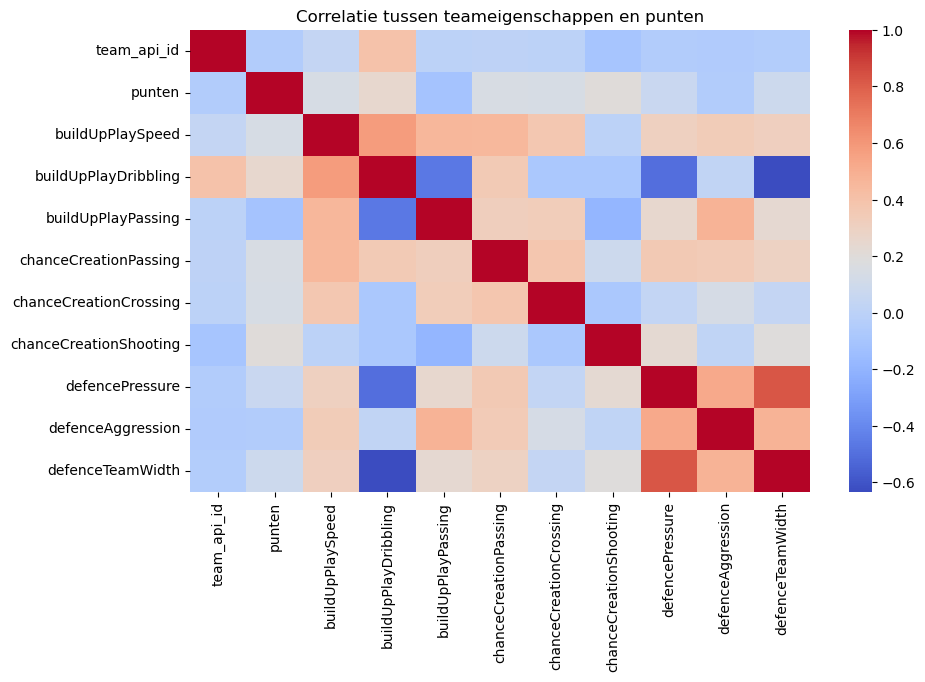

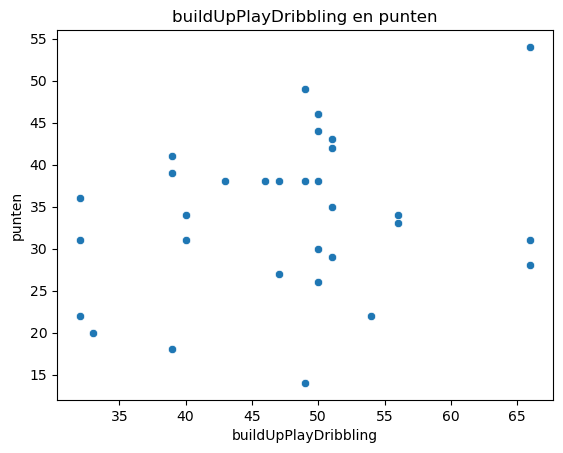

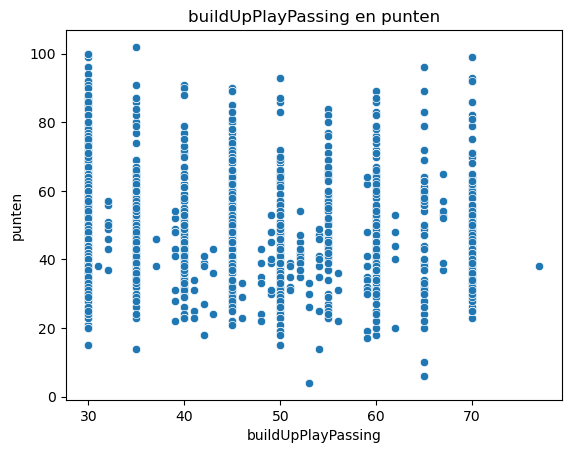

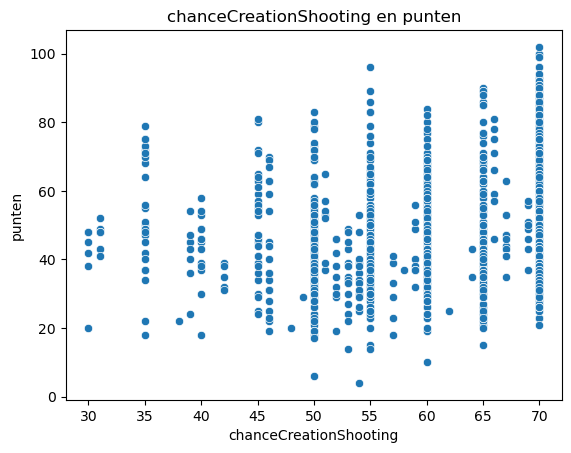

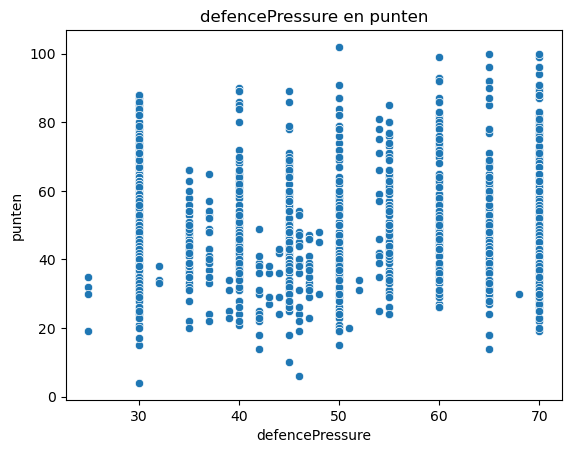

In [13]:

# heatmap
corr = samengevoegd_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlatie tussen teameigenschappen en punten")
plt.show()

variabelen = [
    "buildUpPlayDribbling",
    "buildUpPlayPassing",
    "chanceCreationShooting",
    "defencePressure"
]

for var in variabelen:
    sns.scatterplot(data=samengevoegd_df, x=var, y="punten")
    plt.title(f"{var} en punten")
    plt.show()



## SPRINT 4 

Opdracht 1a: Maak een nieuw dataframe waarin voor iedere speler het gemiddelde van alle relevante spelerseigenschappen ('Player_Attributes') staat 

- we selecteren alle relevante kolommen van `player_attributes` behalve `player_api_id`
- we het gemiddelde per speler
- groupby("player_api_id") = groepeer alle rijen met dezelfde speler
- [relevante_kolommen] = alleen de statistieken meenemen, niet de ID
- .mean() = bereken het gemiddelde per kolom per speler
- .reset_index() = zet player_api_id terug als gewone kolom (niet als index)

In [14]:
def get_gemiddelde_speler_attributen(conn):
    """
    Berekent het gemiddelde van alle spelersstatistieken per speler.

    Elke speler heeft meerdere rijen in de database (één per seizoen/meting).
    Deze functie groepeert alle metingen per speler en berekent het gemiddelde
    van elke statistiek, zodat je één overzichtelijke rij per speler krijgt.

    Parameters
    ----------
    conn : sqlite3.Connection
        De actieve verbinding met de SQLite database.
        Wordt gebruikt om de SQL-query uit te voeren.

    Returns
    -------
    pd.DataFrame
        Een nieuw DataFrame met per speler (player_api_id) het gemiddelde
        van alle relevante spelereigenschappen, afgerond op 2 decimalen.
        Bevat 11.060 spelers en 36 kolommen.
    """

    # we halen alle relevante kolommen op uit Player_Attributes
    # we selecteren handmatig alle statistieken die we willen meenemen
    query = """
    SELECT
        player_api_id,
        overall_rating,
        potential,
        crossing,
        finishing,
        heading_accuracy,
        short_passing,
        volleys,
        dribbling,
        curve,
        free_kick_accuracy,
        long_passing,
        ball_control,
        acceleration,
        sprint_speed,
        agility,
        reactions,
        balance,
        shot_power,
        jumping,
        stamina,
        strength,
        long_shots,
        aggression,
        interceptions,
        positioning,
        vision,
        penalties,
        marking,
        standing_tackle,
        sliding_tackle,
        gk_diving,
        gk_handling,
        gk_kicking,
        gk_positioning,
        gk_reflexes
    FROM Player_Attributes
    """

    # hier voeren we de query uit en laden het resultaat in een DataFrame
    # pd.read_sql_query combineert SQL uitvoeren + inladen in één stap
    df = pd.read_sql_query(query, conn)

    # we selecteren alle kolommen behalve player_api_id (dat is de ID, geen statistiek)
    # we maken een list comprehension
    relevante_kolommen = [col for col in df.columns if col != "player_api_id"]

    # hier berekenen we het gemiddelde per speler
    # groupby("player_api_id") = groepeer alle rijen met dezelfde speler
    # [relevante_kolommen] = alleen de statistieken meenemen, niet de ID
    # .mean() = bereken het gemiddelde per kolom per speler
    # .reset_index() = zet player_api_id terug als gewone kolom (niet als index)
    gemiddelde_df = (
        df.groupby("player_api_id")[relevante_kolommen]
        .mean()
        .reset_index()
    )

    # hier ronden we alle waarden af op 2 decimalen voor leesbaarheid
    gemiddelde_df[relevante_kolommen] = gemiddelde_df[relevante_kolommen].round(2)

    return gemiddelde_df


# als laatst roepen we de functie aan en slaan het resultaat op in speler_gem_df
speler_gem_df = get_gemiddelde_speler_attributen(bar.conn)

display(speler_gem_df.head(10))
print(f"Aantal spelers: {len(speler_gem_df)}")
print(f"Aantal kolommen: {len(speler_gem_df.columns)}")

,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2625,60.14,61.14,50.14,47.29,46.29,56.50,38.00,54.14,50.00,...,55.29,61.93,62.93,63.86,56.57,12.43,12.86,19.07,10.36,10.43
1,2752,69.38,70.38,36.43,37.43,75.33,54.81,20.43,44.86,30.43,...,52.43,35.43,71.10,70.67,65.57,11.10,6.10,7.10,9.10,15.10
2,2768,69.29,70.57,42.24,42.76,66.67,64.71,28.76,40.24,51.76,...,57.76,31.90,71.67,70.62,79.71,10.76,15.90,22.71,15.14,12.10
3,2770,71.13,73.53,61.87,67.67,67.80,72.53,67.13,75.07,79.80,...,71.60,63.93,30.20,37.53,25.00,8.67,15.67,27.20,16.33,17.00
4,2790,70.20,75.80,70.00,37.40,55.20,68.00,43.00,60.80,67.00,...,60.00,55.40,74.60,74.60,69.00,8.00,17.00,59.00,16.60,17.40
5,2796,64.60,70.53,17.93,16.07,19.73,21.20,16.00,17.93,18.53,...,27.27,21.53,17.27,17.93,17.87,73.67,59.00,59.87,57.93,69.53
6,2802,76.32,78.86,77.18,72.64,55.73,71.64,68.27,83.09,80.09,...,76.18,71.36,38.86,43.05,36.00,11.86,16.91,23.00,11.50,9.95
7,2805,72.54,77.82,54.39,41.54,53.82,75.00,26.32,55.54,56.75,...,74.07,52.11,57.86,76.21,63.36,10.11,9.29,18.79,10.18,15.54
8,2857,65.19,68.25,66.75,58.06,47.12,60.81,58.00,68.00,65.69,...,65.25,58.50,27.38,34.38,23.00,10.69,10.81,25.12,9.19,13.25
9,2862,72.91,74.56,68.26,65.88,60.00,70.29,69.85,76.79,70.62,...,70.88,73.06,22.50,23.74,22.79,9.91,15.68,18.68,11.65,8.71


Aantal spelers: 11060
Aantal kolommen: 36


## 1b: Edit de df zodat per speler hun gemiddelde rating te zien is.

- `speler_gem_df` wordt tijdelijk opgeslagen als SQL-tabel, zodat deze gebruikt kan worden in de query.
- De loops gaan langs alle thuis- en uitspelers en maken automatisch de SELECT- en LEFT JOIN-stukken.
- LEFT JOIN koppelt elke speler uit een wedstrijd aan zijn gemiddelde `overall_rating`.
- `", ".join(select_delen)` zet komma’s tussen de kolommen, omdat SQL-kolommen in SELECT gescheiden moeten worden met komma’s.
- `" ".join(join_delen)` plakt alle joins achter elkaar; hierbij zijn geen komma’s nodig.
- `UNION` wordt hier niet gebruikt. `UNION` gebruik je alleen als je meerdere SELECT resultaten onder elkaar wilt zetten.
- De `WHERE` selecteert alleen wedstrijden waarin FC Barcelona meedeed.

In [15]:
# Dataframe van opdracht 1a tijdelijk opslaan als SQL-tabel
# Zo kunnen we speler_gem_df gebruiken in een SQL-query
speler_gem_df.to_sql("speler_gem_df", bar.conn, if_exists="replace", index=False)

# We willen home en away spelers meenemen
teams = ["home", "away"]

# Hier slaan we de stukjes SQL tijdelijk in op
join_delen = []
select_delen = []

# Loop door home en away en door speler 1 t/m 11
for team in teams:
    for nummer in range(1, 12):
        alias = f"{team}_{nummer}"

        # Kolommen maken voor de rating van elke speler
        select_delen.append(
            f"{alias}.overall_rating AS {team}_Player_{nummer}_overall_rating"
        )

        # Speler uit Match koppelen aan zijn gemidelde rating
        join_delen.append(f"""
            LEFT JOIN speler_gem_df AS {alias}
                ON m.{team}_player_{nummer} = {alias}.player_api_id
        """)

# Query maken voor alle wedstrijden van FC Barcelona
query = f"""
SELECT
    m.id AS match_id,
    m.season,
    m.date,
    {", ".join(select_delen)}
FROM Match AS m
{" ".join(join_delen)}
WHERE m.home_team_api_id = 8634
   OR m.away_team_api_id = 8634
ORDER BY m.date;
"""

# Testen
wedstrijd_rating_df = pd.read_sql_query(query, bar.conn)
wedstrijd_rating_df.head(11)

,match_id,season,date,home_Player_1_overall_rating,home_Player_2_overall_rating,home_Player_3_overall_rating,home_Player_4_overall_rating,home_Player_5_overall_rating,home_Player_6_overall_rating,home_Player_7_overall_rating,...,away_Player_2_overall_rating,away_Player_3_overall_rating,away_Player_4_overall_rating,away_Player_5_overall_rating,away_Player_6_overall_rating,away_Player_7_overall_rating,away_Player_8_overall_rating,away_Player_9_overall_rating,away_Player_10_overall_rating,away_Player_11_overall_rating
0,21521,2008/2009,2008-08-31 00:00:00,71.14,66.92,NaN,68.50,69.06,65.50,66.53,...,84.20,85.89,76.43,79.53,87.64,85.03,88.32,92.19,83.78,79.46
1,21630,2008/2009,2008-09-13 00:00:00,83.64,84.20,83.57,85.89,79.53,87.64,78.38,...,72.00,80.93,72.83,65.83,73.63,76.10,72.59,70.91,78.70,73.00
2,21738,2008/2009,2008-09-21 00:00:00,69.00,66.11,67.56,64.67,65.58,68.00,64.85,...,84.20,76.43,85.89,79.53,87.64,78.38,81.44,92.19,83.78,88.32
3,21842,2008/2009,2008-09-24 00:00:00,83.64,84.20,79.32,76.43,79.53,87.64,85.03,...,71.18,68.11,75.89,64.38,74.62,71.29,75.94,75.00,73.78,70.60
4,21853,2008/2009,2008-09-27 00:00:00,78.23,73.06,75.64,75.33,71.45,70.57,68.61,...,84.20,85.89,83.57,79.53,87.64,81.44,88.32,92.19,79.46,72.50
5,21858,2008/2009,2008-10-04 00:00:00,83.64,85.89,83.57,76.43,79.53,81.44,87.64,...,75.76,76.68,79.00,71.93,77.97,78.37,75.92,74.12,86.11,72.16
6,21875,2008/2009,2008-10-19 00:00:00,76.92,77.77,74.20,76.19,73.09,73.54,79.17,...,84.20,76.43,83.57,79.53,71.14,85.03,78.38,88.32,83.78,79.46
7,21884,2008/2009,2008-10-25 00:00:00,83.64,84.20,85.89,76.43,79.53,87.64,85.03,...,69.03,71.10,69.22,67.73,68.85,69.75,69.96,71.87,71.15,81.27
8,21889,2008/2009,2008-11-01 00:00:00,68.29,75.85,67.57,74.61,70.38,74.11,70.78,...,84.20,83.57,76.43,85.89,87.64,85.03,81.44,92.19,83.78,88.32
9,21535,2008/2009,2008-11-08 00:00:00,83.64,84.20,76.43,83.57,85.89,72.50,85.03,...,72.16,71.22,74.50,70.20,72.48,72.64,71.80,77.44,72.50,70.10


## Data preparation

In deze code wordt de data klaargemaakt voor opdracht 1c.

Eerst kies ik één competitie en één seizoen:

- Competitie: `Spain LIGA BBVA`
- Seizoen: `2015/2016`

Daarna gebruik ik de functie `lees_sql()` om SQL-query’s uit te voeren op de database.

Met de functie `maak_dataset()` wordt de echte dataset gemaakt:

- De punten per team worden berekend op basis van winst, gelijkspel of verlies.
- De spelers uit de wedstrijden worden uit de kolommen gehaald en omgezet naar losse rijen.
- Per speler wordt de gemiddelde `overall_rating` en `potential` berekend.
- Daarna wordt dit eerst gemiddeld per wedstrijd.
- Vervolgens wordt dit gemiddeld per team over het hele seizoen.
- Als laatste worden de punten, teamnamen en gemiddelde spelersstatistieken samengevoegd in één dataframe.

De uiteindelijke dataset heet `df`. Deze dataset gebruik ik daarna voor de visualisaties.

In [16]:
competitie = "Spain LIGA BBVA"
seizoen = "2015/2016"

def lees_sql(query):
    return pd.read_sql_query(query, bar.conn)


def maak_dataset():
    spelers = " UNION ALL ".join([
        f"""
        SELECT id AS match_id, home_team_api_id AS team_api_id, home_player_{i} AS player_api_id FROM Match
        UNION ALL
        SELECT id AS match_id, away_team_api_id AS team_api_id, away_player_{i} AS player_api_id FROM Match
        """
        for i in range(1, 12)
    ])

    query = f"""
    WITH punten AS (
        SELECT home_team_api_id AS team_api_id,
               CASE WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match m
        JOIN League l 
            ON m.league_id = l.id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'

        UNION ALL

        SELECT away_team_api_id AS team_api_id,
               CASE WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match m
        JOIN League l 
            ON m.league_id = l.id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'
    ),

    punten_team AS (
        SELECT team_api_id, SUM(punten) AS punten
        FROM punten
        GROUP BY team_api_id
    ),

    spelers AS ({spelers}),

    speler_stat AS (
        SELECT 
            player_api_id,
            AVG(overall_rating) AS overall_rating,
            AVG(potential) AS potential
        FROM Player_Attributes
        GROUP BY player_api_id
    ),

    per_wedstrijd AS (
        SELECT 
            s.match_id,
            s.team_api_id,
            AVG(ps.overall_rating) AS wedstrijd_overall_rating,
            AVG(ps.potential) AS wedstrijd_potential
        FROM spelers s
        JOIN Match m 
            ON s.match_id = m.id
        JOIN League l 
            ON m.league_id = l.id
        JOIN speler_stat ps 
            ON s.player_api_id = ps.player_api_id
        WHERE l.name = '{competitie}' AND m.season = '{seizoen}'
        GROUP BY s.match_id, s.team_api_id
    ),

    per_seizoen AS (
        SELECT 
            team_api_id,
            AVG(wedstrijd_overall_rating) AS gemiddelde_overall_rating,
            AVG(wedstrijd_potential) AS gemiddelde_potential
        FROM per_wedstrijd
        GROUP BY team_api_id
    )

    SELECT 
        t.team_long_name AS team,
        p.team_api_id,
        p.punten,
        s.gemiddelde_overall_rating,
        s.gemiddelde_potential
    FROM punten_team p
    JOIN per_seizoen s 
        ON p.team_api_id = s.team_api_id
    JOIN Team t 
        ON p.team_api_id = t.team_api_id
    """

    return lees_sql(query)


df = maak_dataset()
display(df)

,team,team_api_id,punten,gemiddelde_overall_rating,gemiddelde_potential
0,Granada CF,7878,39,69.183339,75.797182
1,Sevilla FC,8302,52,74.053998,79.160183
2,Getafe CF,8305,36,71.840017,76.863744
3,UD Las Palmas,8306,44,68.809110,73.258304
4,Athletic Club de Bilbao,8315,62,73.982956,78.151267
5,Rayo Vallecano,8370,38,69.533443,74.064096
6,SD Eibar,8372,43,68.272380,74.018387
7,RCD Espanyol,8558,43,68.579595,74.548570
8,Real Sociedad,8560,48,72.392561,78.347162
9,Levante UD,8581,32,70.286200,74.977605


## 1.2C Visualisatie en interpretatie

- De tabel laat per team het aantal punten en de gemiddelde `overall_rating` zien.
- De scatterplot laat de relatie zien tussen `overall_rating` en punten.
- De teamnamen staan erbij, zodat duidelijk is welke club bij welk punt hoort.
- Zo kun je checken of teams met betere spelers ook meer punten hebben gehaald.


,team,punten,gemiddelde_overall_rating
12,FC Barcelona,91,81.596763
11,Real Madrid CF,90,80.393950
16,Atlético Madrid,88,76.844984
18,Villarreal CF,64,72.651592
4,Athletic Club de Bilbao,62,73.982956
17,RC Celta de Vigo,60,70.753108
1,Sevilla FC,52,74.053998
14,Málaga CF,48,72.188289
8,Real Sociedad,48,72.392561
10,Real Betis Balompié,45,70.637098


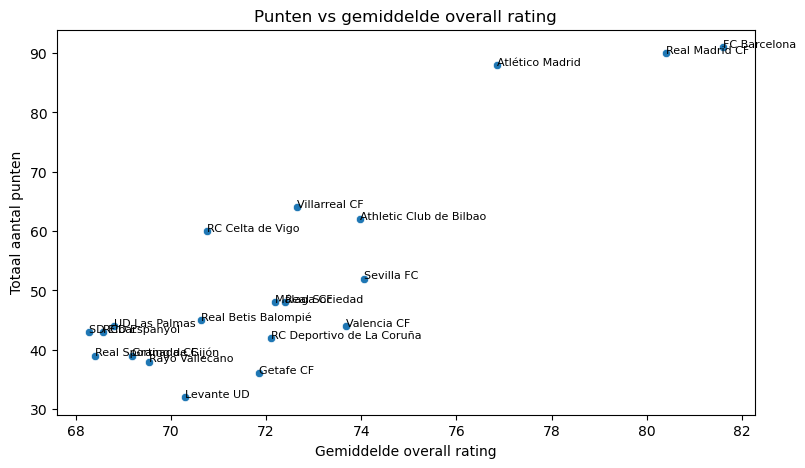

In [17]:
df = maak_dataset()

# Tabel voor overall rating
tabel_overall = df[[
    "team",
    "punten",
    "gemiddelde_overall_rating"
]].sort_values("punten", ascending=False)

display(tabel_overall)

# Visualisatie overall rating
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="gemiddelde_overall_rating",
    y="punten"
)

for index, rij in df.iterrows():
    plt.text(
        rij["gemiddelde_overall_rating"],
        rij["punten"],
        rij["team"],
        fontsize=8
    )

plt.title("Punten vs gemiddelde overall rating")
plt.xlabel("Gemiddelde overall rating")
plt.ylabel("Totaal aantal punten")
plt.show()




# Sprint 5



## Opdracht 1

### Opdr 1.1
- Vorm: `Supervised learning`
- Sub-vorm: `Multiclass classification`

Omdat je 1 van 3 vaste klassen voorspelt: win, defeat of draw, op basis van spelereigenschappen en teameigenschappen.



### opdr 1.2

- Met `CASE WHEN` wordt gekeken welk team heeft gewonnen.
- Als `home_team_goal` groter is dan `away_team_goal`, wint het thuisteam.
- Als `away_team_goal` groter is dan `home_team_goal`, wint het uitteam.
- Als beide scores gelijk zijn, is het een gelijkspel.
- Het resultaat wordt toegevoegd als nieuwe kolom: `resultaat`.

In [18]:
match_df = pd.read_sql_query("""
SELECT
    *,
    CASE
        WHEN home_team_goal > away_team_goal THEN 'Thuisteam wint'
        WHEN home_team_goal < away_team_goal THEN 'Uitteam wint'
        ELSE 'Gelijkspel'
    END AS resultaat
FROM Match
""", bar.conn)

match_df[[
    "id",
    "season",
    "home_team_api_id",
    "away_team_api_id",
    "home_team_goal",
    "away_team_goal",
    "resultaat"
]]

,id,season,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,resultaat
0,1,2008/2009,9987,9993,1,1,Gelijkspel
1,2,2008/2009,10000,9994,0,0,Gelijkspel
2,3,2008/2009,9984,8635,0,3,Uitteam wint
3,4,2008/2009,9991,9998,5,0,Thuisteam wint
4,5,2008/2009,7947,9985,1,3,Uitteam wint
...,...,...,...,...,...,...,...
25974,25975,2015/2016,10190,10191,1,0,Thuisteam wint
25975,25976,2015/2016,9824,10199,1,2,Uitteam wint
25976,25977,2015/2016,9956,10179,2,0,Thuisteam wint
25977,25978,2015/2016,7896,10243,0,0,Gelijkspel


# Opdracht 1.3 - Features kiezen

Voor het voorspellen van het resultaat gebruiken we de **spelers eigenschappen** en **team eigenschappen**.
We willen voorspellen of Barcelona een wedstrijd wint, verliest of gelijk speelt.

> Het doel is niet om zoveel mogelijk features te gebruiken, maar om features te kiezen die een werkelijke invloed kunnen hebben op het resultaat van een wedstrijd.



Het resultaat van een wedstrijd hangt niet alleen af van individuele spelers, maar ook van de team opbouw, 'chance creation', enzovoorts wat ook invloed heeft op het resultaat.  
Daarom maken wij gebruik van gegevens uit twee tabellen:

1. `Player_Attributes` voor de eigenschappen van de spelers.
2. `Team_Attributes` voor de 'playstyle' en tactische eigenschappen van het team.

## Spelers eigenschappen - `Player_Attributes`

We gebruiken eerst de eigenschappen van de spelers.  
Deze features geven informatie over de algemene kwaliteit, aanvallende kwaliteiten, fysieke kwaliteiten en verdedigende kwaliteiten van de spelers.

### Features die we meenemen

| Onderdeel | Features | Waarom we deze gebruiken |
|---|---|---|
| Algemene kwaliteit | `overall_rating`, `potential` | `overall_rating` geeft een algemeen beeld van hoe goed een speler is. `potential` nemen we voorlopig mee omdat een team met spelers met meer kwaliteit en ontwikkelpotentieel vaak ook een sterkere selectie heeft. |
| Aanvallende kwaliteit | `finishing`, `dribbling`, `ball_control` | Deze features kunnen belangrijk zijn bij het creëren en afmaken van kansen. Een team met spelers die goed kunnen dribbelen en de bal goed controleren kan makkelijker gevaarlijk worden. |
| Passing | `short_passing` | Barcelona speelt veel met korte passes en balbezit. Daarom kan deze feature belangrijk zijn voor de manier waarop het team aanvallen opbouwt. |
| Snelheid en conditie | `sprint_speed`, `stamina`, `strength` | Deze features geven aan hoe spelers fysiek presteren. Spelers moeten snelheid en conditie hebben om gedurende de wedstrijd goed te blijven spelen. |
| Reactievermogen | `reactions` | Een speler met goede reacties kan sneller handelen in belangrijke situaties, bijvoorbeeld bij balverlies of een kans voor het doel. |
| Verdedigende kwaliteit | `interceptions`, `marking`, `standing_tackle` | Deze features geven aan hoe goed spelers de tegenstander kunnen verdedigen en de bal terug kunnen winnen. |

De gekozen spelers features zijn:

```overall_rating
potential
finishing
short_passing
dribbling
ball_control
sprint_speed
stamina
strength
reactions
interceptions
marking
standing_tackle

## Team eigenschappen - `Team_Attributes`

Daarna gebruiken we de eigenschappen van het team.
Deze features geven informatie over hoe het team speelt, aanvallen opbouwt, kansen creëert en verdedigt.

### Features die we meenemen

| Onderdeel | Feature | waarom we deze feature gebruiken
|---|---|---|
| Opbouw van het spel | `buildUpPlaySpeed`, `buildUpPlayDribbling`, `buildUpPlayPassing` | Deze features geven aan hoe het team vanuit achteren het spel opbouwt en hoe snel het naar voren speelt.
| Kansen creëren | `chanceCreationPassing`, `chanceCreationCrossing`, `chanceCreationShooting` | Deze features geven aan hoe het team probeert tot kansen en schoten te komen. Dit kan direct invloed hebben op het aantal doelpunten. |
| Verdedigende speelstijl | `defencePressure`, `defenceAggression`, `defenceTeamWidth` | Deze features geven aan hoe het team verdedigt, druk zet en de ruimte op het veld gebruikt. Dit kan invloed hebben op hoeveel kansen de tegenstander krijgt. |

De gekozen features zijn dus:
```buildUpPlaySpeed
buildUpPlayDribbling
buildUpPlayPassing
chanceCreationPassing
chanceCreationCrossing
chanceCreationShooting
defencePressure
defenceAggression
defenceTeamWidth

In [19]:
speler_features = [
    "overall_rating",
    "potential",
    "finishing",
    "short_passing",
    "dribbling",
    "ball_control",
    "sprint_speed",
    "stamina",
    "strength",
    "reactions",
    "interceptions",
    "marking",
    "standing_tackle"
]

team_features = [
    "buildUpPlaySpeed",
    "buildUpPlayDribbling",
    "buildUpPlayPassing",
    "chanceCreationPassing",
    "chanceCreationCrossing",
    "chanceCreationShooting",
    "defencePressure",
    "defenceAggression",
    "defenceTeamWidth"
]


def selecteer_features(conn, tabelnaam, verbind_kolommen, features):

    """
    Haalt de gekozen features uit een tabel in de database.

    De verbind_kolommen worden meegenomen omdat deze later nodig zijn om de features aan de juiste wedstrijden te koppelen.
    Ze voorspellen zelf niets, maar zijn essentieel voor het correct samenvoegen van de data.

    Parameters
   
    conn : sqlite3.Connection
    De verbinding met de database.

    tabelnaam : str
    De naam van de tabel waaruit de features worden opgehaald.

    verbind_kolommen : list
    Kolommen die later nodig zijn om de data te koppelen.

    features : list
    De gekozen features voor het voorspellen van het resultaat.

    Returns
   
    pd.DataFrame
        Een dataframe met de verbind_kolommen en de gekozen features.
    """

    toegestane_tabellen = ["Player_Attributes", "Team_Attributes"]

    if tabelnaam not in toegestane_tabellen:
        raise ValueError(
            f"De tabel '{tabelnaam}' mag niet gebruikt worden."
        )

    geselecteerde_kolommen = verbind_kolommen + features
    kolommen_sql = ", ".join(geselecteerde_kolommen)

    query = f"""
    SELECT
        {kolommen_sql}
    FROM {tabelnaam}
    """

    return pd.read_sql_query(query, conn)


# Gekozen spelers features ophalen
speler_features_df = selecteer_features(
    conn = bar.conn,
    tabelnaam = "Player_Attributes",
    verbind_kolommen = ["player_api_id", "date"],
    features = speler_features
)


# Gekozen team features ophalen
team_features_df = selecteer_features(
    conn = bar.conn,
    tabelnaam = "Team_Attributes",
    verbind_kolommen = ["team_api_id", "date"],
    features = team_features
)



print("Gekozen features uit Player_Attributes:")
display(speler_features_df.head())

print("Gekozen features uit Team_Attributes:")
display(team_features_df.head())

Gekozen features uit Player_Attributes:


,player_api_id,date,overall_rating,potential,finishing,short_passing,dribbling,ball_control,sprint_speed,stamina,strength,reactions,interceptions,marking,standing_tackle
0,505942,2016-02-18 00:00:00,67.0,71.0,44.0,61.0,51.0,49.0,64.0,54.0,76.0,47.0,70.0,65.0,69.0
1,505942,2015-11-19 00:00:00,67.0,71.0,44.0,61.0,51.0,49.0,64.0,54.0,76.0,47.0,70.0,65.0,69.0
2,505942,2015-09-21 00:00:00,62.0,66.0,44.0,61.0,51.0,49.0,64.0,54.0,76.0,47.0,41.0,65.0,66.0
3,505942,2015-03-20 00:00:00,61.0,65.0,43.0,60.0,50.0,48.0,64.0,54.0,76.0,46.0,40.0,62.0,63.0
4,505942,2007-02-22 00:00:00,61.0,65.0,43.0,60.0,50.0,48.0,64.0,54.0,76.0,46.0,40.0,62.0,63.0


Gekozen features uit Team_Attributes:


,team_api_id,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,9930,2010-02-22 00:00:00,60,NaN,50,60,65,55,50,55,45
1,9930,2014-09-19 00:00:00,52,48.0,56,54,63,64,47,44,54
2,9930,2015-09-10 00:00:00,47,41.0,54,54,63,64,47,44,54
3,8485,2010-02-22 00:00:00,70,NaN,70,70,70,70,60,70,70
4,8485,2011-02-22 00:00:00,47,NaN,52,53,48,52,47,47,52


# Opdr 1.4 - Nieuw dataframe maken

In deze opdracht maken we een nieuw dataframe met alleen de gekozen features en het resultaat per wedstrijd.

Hiervoor gebruiken we een zelf gedefinieerde preprocessing class. Deze class koppelt de gekozen spelers eigenschappen en team eigenschappen aan iedere wedstrijd.

Omdat iedere wedstrijd bestaat uit een thuisteam en uitteam, berekenen we per feature het verschil tussen deze twee teams.

Bijvoorbeeld:

`overall_rating_verschil = overall_rating thuisteam - overall_rating uitteam`

Wanneer de waarde positief is, scoort het thuisteam hoger op die feature. Wanneer de waarde negatief is, scoort het uitteam hoger.

Het uiteindelijke dataframe bevat hierdoor alleen de verschilfeatures en de kolom `resultaat`.

> Iedere rij in het nieuwe dataframe staat voor één wedstrijd.

In [20]:
class WedstrijdPreprocessor:
    """
    Maakt een nieuw dataframe met alleen de gekozen features
    en het resultaat per wedstrijd.

    De gekozen features worden omgezet naar verschilfeatures:
    gemiddelde eigenschap thuisteam - gemiddelde eigenschap uitteam.
    """

    def __init__(self, speler_features, team_features):
        """
        Slaat de gekozen speler- en teamfeatures op.

        Parameters
        
        speler_features : list
            De gekozen features uit Player_Attributes.
        team_features : list
            De gekozen features uit Team_Attributes.
        """
        self.speler_features = speler_features
        self.team_features = team_features
        self.alle_features = speler_features + team_features

    @staticmethod
    def controleer_kolommen(dataframe, nodige_kolommen, dataframe_naam):
        """
        Controleert of alle nodige kolommen aanwezig zijn.

        Parameters
        
        dataframe : pd.DataFrame
            Het dataframe dat gecontroleerd wordt.
        nodige_kolommen : list
            De kolommen die aanwezig moeten zijn.
        dataframe_naam : str
            De naam van het dataframe voor een duidelijke foutmelding.

        Raises
        
        ValueError
            Wanneer één of meerdere kolommen ontbreken.
        """
        ontbrekende_kolommen = [
            kolom for kolom in nodige_kolommen
            if kolom not in dataframe.columns
        ]

        if ontbrekende_kolommen:
            raise ValueError(
                f"De volgende kolommen ontbreken in {dataframe_naam}: "
                f"{ontbrekende_kolommen}"
            )

    @staticmethod
    def koppel_op_datum(rijen_df, attributen_df, id_kolom):
        """
        Koppelt de meest recente attributen aan de datum van de wedstrijd.

        Er worden alleen gegevens gebruikt die op of voor de wedstrijddatum
        beschikbaar waren.

        Parameters
        
        rijen_df : pd.DataFrame
            Dataframe met wedstrijden, datum en een speler- of team-id.
        attributen_df : pd.DataFrame
            Dataframe met attributen en datums.
        id_kolom : str
            De kolom waarop gekoppeld wordt.

        Returns
        
        pd.DataFrame
            Dataframe met de gekoppelde attributen.
        """
        return pd.merge_asof(
            rijen_df.sort_values("date"),
            attributen_df.sort_values("date"),
            on = "date",
            by = id_kolom,
            direction = "backward"
        )

    def maak_speler_features(self, wedstrijden_df, speler_attributen_df):
        """
        Berekent voor iedere wedstrijd de gemiddelde spelerseigenschappen
        van het thuisteam en het uitteam.

        Parameters
        
        wedstrijden_df : pd.DataFrame
            Dataframe met de wedstrijden en spelers per wedstrijd.
        speler_attributen_df : pd.DataFrame
            Dataframe met de gekozen spelerseigenschappen.

        Returns
        
        pd.DataFrame
            Dataframe met gemiddelde spelers features per wedstrijd.
        """
        speler_resultaat_df = wedstrijden_df[["id"]].rename(
            columns = {"id": "match_id"}
        ).copy()

        speler_attributen_df = speler_attributen_df.copy()
        speler_attributen_df["date"] = pd.to_datetime(
            speler_attributen_df["date"]
        )

        speler_attributen_df = speler_attributen_df.dropna(
            subset = ["player_api_id", "date"]
        )

        speler_attributen_df["player_api_id"] = speler_attributen_df[
            "player_api_id"
        ].astype(int)

        for kant in ["home", "away"]:
            speler_kolommen = [
                f"{kant}_player_{nummer}"
                for nummer in range(1, 12)
            ]

            spelers_lang_df = wedstrijden_df[
                ["id", "date"] + speler_kolommen
            ].melt(
                id_vars = ["id", "date"],
                value_vars = speler_kolommen,
                value_name = "player_api_id"
            )

            spelers_lang_df = spelers_lang_df.dropna(
                subset = ["player_api_id"]
            ).copy()

            spelers_lang_df["player_api_id"] = spelers_lang_df[
                "player_api_id"
            ].astype(int)

            gekoppeld_df = self.koppel_op_datum(
                rijen_df = spelers_lang_df[["id", "date", "player_api_id"]],
                attributen_df = speler_attributen_df,
                id_kolom = "player_api_id"
            )

            gemiddelde_df = (
                gekoppeld_df
                .groupby("id", as_index=False)[self.speler_features]
                .mean()
                .rename(columns = {
                    "id": "match_id",
                    **{
                        feature: f"{kant}_{feature}"
                        for feature in self.speler_features
                    }
                })
            )

            speler_resultaat_df = speler_resultaat_df.merge(
                gemiddelde_df,
                on = "match_id",
                how = "left"
            )

        return speler_resultaat_df

    def maak_team_features(self, wedstrijden_df, team_attributen_df):
        """
        Koppelt de gekozen team eigenschappen van het thuisteam
        en het uitteam aan iedere wedstrijd.

        Parameters
        
        wedstrijden_df : pd.DataFrame
            Dataframe met de wedstrijden.
        team_attributen_df : pd.DataFrame
            Dataframe met de gekozen team eigenschappen.

        Returns
        
        pd.DataFrame
            Dataframe met team features per wedstrijd.
        """
        team_resultaat_df = wedstrijden_df[["id"]].rename(
            columns={"id": "match_id"}
        ).copy()

        team_attributen_df = team_attributen_df.copy()
        team_attributen_df["date"] = pd.to_datetime(
            team_attributen_df["date"]
        )

        team_attributen_df = team_attributen_df.dropna(
            subset=["team_api_id", "date"]
        )

        team_attributen_df["team_api_id"] = team_attributen_df[
            "team_api_id"
        ].astype(int)

        for kant in ["home", "away"]:
            teams_per_wedstrijd_df = wedstrijden_df[
                ["id", "date", f"{kant}_team_api_id"]
            ].rename(columns={
                f"{kant}_team_api_id": "team_api_id"
            }).copy()

            teams_per_wedstrijd_df["team_api_id"] = teams_per_wedstrijd_df[
                "team_api_id"
            ].astype(int)

            gekoppeld_df = self.koppel_op_datum(
                rijen_df=teams_per_wedstrijd_df,
                attributen_df=team_attributen_df,
                id_kolom="team_api_id"
            )

            geselecteerd_df = gekoppeld_df[
                ["id"] + self.team_features
            ].rename(columns={
                "id": "match_id",
                **{
                    feature: f"{kant}_{feature}"
                    for feature in self.team_features
                }
            })

            team_resultaat_df = team_resultaat_df.merge(
                geselecteerd_df,
                on="match_id",
                how="left"
            )

        return team_resultaat_df

    def maak_verschil_features(self, gekoppeld_df):
        """
        Maakt verschilfeatures door de waarde van het uitteam
        af te trekken van de waarde van het thuisteam.

        Parameters
        
        gekoppeld_df : pd.DataFrame
            Dataframe met features van thuis- en uitteams.

        Returns
        
        pd.DataFrame
            Dataframe met alleen verschilfeatures en resultaat.
        """
        nieuw_df = pd.DataFrame()

        for feature in self.alle_features:
            nieuw_df[f"{feature}_verschil"] = (
                gekoppeld_df[f"home_{feature}"] -
                gekoppeld_df[f"away_{feature}"]
            )

        nieuw_df["resultaat"] = gekoppeld_df["resultaat"]

        return nieuw_df

    def maak_dataframe(self, match_df, speler_attributen_df, team_attributen_df):
        """
        Maakt het uiteindelijke dataframe met alleen de gekozen
        verschilfeatures en het resultaat per wedstrijd.

        Parameters
        
        match_df : pd.DataFrame
            Het dataframe uit opdracht 1.2 met de kolom resultaat.
        speler_attributen_df : pd.DataFrame
            Het dataframe uit opdracht 1.3 met de gekozen speler features.
        team_attributen_df : pd.DataFrame
            Het dataframe uit opdracht 1.3 met de gekozen team features.

        Returns
        
        pd.DataFrame
            Nieuw dataframe met alleen features en resultaat per wedstrijd.
        """
        speler_kolommen = [
            f"{kant}_player_{nummer}"
            for kant in ["home", "away"]
            for nummer in range(1, 12)
        ]

        nodige_match_kolommen = [
            "id",
            "date",
            "home_team_api_id",
            "away_team_api_id",
            "resultaat"
        ] + speler_kolommen

        self.controleer_kolommen(
            dataframe = match_df,
            nodige_kolommen = nodige_match_kolommen,
            dataframe_naam = "match_df"
        )

        wedstrijden_df = match_df[nodige_match_kolommen].copy()
        wedstrijden_df["date"] = pd.to_datetime(wedstrijden_df["date"])

        speler_df = self.maak_speler_features(
            wedstrijden_df = wedstrijden_df,
            speler_attributen_df = speler_attributen_df
        )

        team_df = self.maak_team_features(
            wedstrijden_df = wedstrijden_df,
            team_attributen_df = team_attributen_df
        )

        gekoppeld_df = (
            wedstrijden_df[["id", "resultaat"]]
            .rename(columns = {"id": "match_id"})
            .merge(speler_df, on = "match_id", how = "left")
            .merge(team_df, on = "match_id", how = "left")
        )

        nieuw_df = self.maak_verschil_features(gekoppeld_df)

        return nieuw_df.dropna().reset_index(drop=True)

In [21]:
# Die preprocessing class gebruiken

preprocessor = WedstrijdPreprocessor(
    speler_features=speler_features,
    team_features=team_features
)

model_df = preprocessor.maak_dataframe(
    match_df=match_df,
    speler_attributen_df=speler_features_df,
    team_attributen_df=team_features_df
)

display(model_df.head())

print("\nVerdeling van het resultaat:")
display(model_df["resultaat"].value_counts())



,overall_rating_verschil,potential_verschil,finishing_verschil,short_passing_verschil,dribbling_verschil,ball_control_verschil,sprint_speed_verschil,stamina_verschil,strength_verschil,reactions_verschil,...,buildUpPlaySpeed_verschil,buildUpPlayDribbling_verschil,buildUpPlayPassing_verschil,chanceCreationPassing_verschil,chanceCreationCrossing_verschil,chanceCreationShooting_verschil,defencePressure_verschil,defenceAggression_verschil,defenceTeamWidth_verschil,resultaat
0,1.363636,1.545455,7.272727,2.272727,5.181818,2.363636,-4.000000,-0.727273,3.454545,2.000000,...,-12.0,7.0,-17.0,-13.0,-1.0,-13.0,6.0,-4.0,5.0,Thuisteam wint
1,3.727273,6.909091,1.454545,2.636364,4.727273,4.545455,3.000000,0.818182,-5.272727,3.545455,...,-6.0,-6.0,13.0,-7.0,5.0,-9.0,13.0,5.0,10.0,Gelijkspel
2,-0.181818,-0.818182,-3.545455,0.090909,-2.000000,-3.090909,0.454545,-3.818182,-2.181818,-2.181818,...,18.0,7.0,6.0,11.0,-17.0,18.0,-4.0,3.0,-3.0,Uitteam wint
3,4.090909,3.818182,0.545455,5.636364,6.818182,9.090909,7.818182,7.272727,-1.909091,5.454545,...,10.0,-4.0,-2.0,-3.0,8.0,9.0,3.0,5.0,8.0,Thuisteam wint
4,-1.545455,-1.181818,-11.636364,-9.181818,-4.636364,-3.363636,0.727273,-6.363636,-4.818182,-4.545455,...,15.0,2.0,7.0,9.0,0.0,29.0,-6.0,-9.0,28.0,Thuisteam wint



Verdeling van het resultaat:


resultaat
Thuisteam wint    2481
Uitteam wint      1676
Gelijkspel        1413
Name: count, dtype: int64

# Opdr 1.5 - Features naar dezelfde schaal omzetten

In deze opdracht zetten we alle gekozen features naar dezelfde schaal om.

De features hebben niet allemaal dezelfde waarden. Sommige features kunnen grotere getallen hebben dan andere features. Hierdoor kan een model meer invloed geven aan features met grotere waarden, terwijl deze niet automatisch belangrijker zijn.

Daarom gebruiken we `StandardScaler`. Deze scaler zet de numerieke features om zodat ze gemiddeld rond de waarde `0` liggen en ongeveer een standaardafwijking van `1` hebben.

De kolom `resultaat` wordt niet geschaald, omdat dit de waarde is die we uiteindelijk willen voorspellen.

> Alleen de features worden geschaald. Het resultaat blijft hetzelfde.

In [22]:
from sklearn.preprocessing import StandardScaler


def schaal_features(dataframe, doelkolom):
    """
    Zet alle numerieke features in een dataframe naar dezelfde schaal om.

    De doelkolom wordt niet geschaald, omdat deze de uitkomst bevat
    die later voorspeld moet worden.

    Parameters

    dataframe : pd.DataFrame
        Het dataframe met de gekozen features en het resultaat.
    doelkolom : str
        De naam van de kolom die niet geschaald moet worden.

    Returns

    pd.DataFrame
        Een nieuw dataframe met geschaalde features en het originele resultaat.
    StandardScaler
        De gebruikte scaler, zodat deze later opnieuw gebruikt kan worden.
    """

    geschaald_df = dataframe.copy()

    feature_kolommen = [
        kolom for kolom in geschaald_df.columns
        if kolom != doelkolom
    ]

    scaler = StandardScaler()

    geschaald_df[feature_kolommen] = scaler.fit_transform(
        geschaald_df[feature_kolommen]
    )

    return geschaald_df, scaler


geschaald_model_df, scaler = schaal_features(
    dataframe = model_df,
    doelkolom = "resultaat"
)

display(geschaald_model_df.head())

,overall_rating_verschil,potential_verschil,finishing_verschil,short_passing_verschil,dribbling_verschil,ball_control_verschil,sprint_speed_verschil,stamina_verschil,strength_verschil,reactions_verschil,...,buildUpPlaySpeed_verschil,buildUpPlayDribbling_verschil,buildUpPlayPassing_verschil,chanceCreationPassing_verschil,chanceCreationCrossing_verschil,chanceCreationShooting_verschil,defencePressure_verschil,defenceAggression_verschil,defenceTeamWidth_verschil,resultaat
0,0.269643,0.299968,1.128407,0.435922,0.867239,0.448921,-0.771997,-0.137252,0.711879,0.346929,...,-0.860530,0.590159,-1.149932,-0.907310,-0.072594,-0.888393,0.476149,-0.362001,0.480468,Thuisteam wint
1,0.763664,1.378784,0.192236,0.507215,0.789141,0.881937,0.567125,0.174974,-1.082050,0.620694,...,-0.429646,-0.514692,0.877241,-0.488042,0.350732,-0.615260,1.029174,0.460587,0.959955,Gelijkspel
2,-0.053371,-0.175442,-0.612286,0.008162,-0.366715,-0.633618,0.080171,-0.761704,-0.446700,-0.393848,...,1.293889,0.590159,0.404234,0.769762,-1.201463,1.228388,-0.313887,0.277790,-0.286711,Uitteam wint
3,0.839668,0.757094,0.045959,1.095385,1.148394,1.784052,1.488858,1.478978,-0.390640,0.958875,...,0.719377,-0.344715,-0.136346,-0.208530,0.562395,0.613838,0.239138,0.460587,0.768160,Thuisteam wint
4,-0.338384,-0.248582,-1.914149,-1.809816,-0.819685,-0.687745,0.132345,-1.275960,-0.988616,-0.812547,...,1.078447,0.165216,0.471806,0.630006,-0.002039,1.979504,-0.471894,-0.818995,2.686107,Thuisteam wint


In [23]:
# Deze codeblock is bedoeld als controle om te laten zien dat het schalen correct is uitgevoerd.
controle_df = geschaald_model_df.drop(columns = ["resultaat"])

print("Gemiddelde per feature na het schalen:")
display(controle_df.mean().round(2))

print("Standaardafwijking per feature after scaling:")
display(controle_df.std().round(2))

print("Resultaat:")
display(geschaald_model_df["resultaat"].value_counts())

Gemiddelde per feature na het schalen:


overall_rating_verschil            0.0
potential_verschil                -0.0
finishing_verschil                -0.0
short_passing_verschil            -0.0
dribbling_verschil                 0.0
ball_control_verschil             -0.0
sprint_speed_verschil             -0.0
stamina_verschil                   0.0
strength_verschil                  0.0
reactions_verschil                -0.0
interceptions_verschil            -0.0
marking_verschil                   0.0
standing_tackle_verschil          -0.0
buildUpPlaySpeed_verschil          0.0
buildUpPlayDribbling_verschil      0.0
buildUpPlayPassing_verschil       -0.0
chanceCreationPassing_verschil     0.0
chanceCreationCrossing_verschil    0.0
chanceCreationShooting_verschil    0.0
defencePressure_verschil           0.0
defenceAggression_verschil         0.0
defenceTeamWidth_verschil          0.0
dtype: float64

Standaardafwijking per feature after scaling:


overall_rating_verschil            1.0
potential_verschil                 1.0
finishing_verschil                 1.0
short_passing_verschil             1.0
dribbling_verschil                 1.0
ball_control_verschil              1.0
sprint_speed_verschil              1.0
stamina_verschil                   1.0
strength_verschil                  1.0
reactions_verschil                 1.0
interceptions_verschil             1.0
marking_verschil                   1.0
standing_tackle_verschil           1.0
buildUpPlaySpeed_verschil          1.0
buildUpPlayDribbling_verschil      1.0
buildUpPlayPassing_verschil        1.0
chanceCreationPassing_verschil     1.0
chanceCreationCrossing_verschil    1.0
chanceCreationShooting_verschil    1.0
defencePressure_verschil           1.0
defenceAggression_verschil         1.0
defenceTeamWidth_verschil          1.0
dtype: float64

Resultaat:


resultaat
Thuisteam wint    2481
Uitteam wint      1676
Gelijkspel        1413
Name: count, dtype: int64

# Opdracht 2 Persoonsgegevens

## Welke persoonsdata worden er verzameld?

In dit project maken we gebruik van de European Soccer Database. De data bevat informatie over individuele spelers, gekoppeld via een `player_api_id`. De volgende persoonsgebonden gegevens worden gebruikt in ons model:

**Spelerseigenschappen (Player_Attributes):**

| Feature | Omschrijving |
|---|---|
| `overall_rating` | Algemene beoordeling van de speler |
| `potential` | Ontwikkelpotentieel van de speler |
| `finishing` | Afronding bij schoten op doel |
| `short_passing` | Kwaliteit van korte passes |
| `dribbling` | Dribbelvaardigheid |
| `ball_control` | Balcontrole |
| `sprint_speed` | Sprintsnelheid |
| `stamina` | Uithoudingsvermogen |
| `strength` | Fysieke kracht |
| `reactions` | Reactievermogen |
| `interceptions` | Vermogen om ballen te onderscheppen |
| `marking` | Bewakingsvaardigheid |
| `standing_tackle` | Tackles terwijl staand |

Al deze attributen zijn herleidbaar tot een individuele speler via de `player_api_id`. Dat maakt het persoonsgegevens in de zin van de AVG, ook al staan er geen namen of BSN-nummers in. Via de ID's kun je immers achterhalen om welke speler het gaat zeker als je dit koppelt aan de spelerstabel in dezelfde database.

Teameigenschappen zoals `buildUpPlaySpeed` of `defencePressure` zijn niet herleidbaar tot individuele personen en vallen daardoor buiten de definitie van persoonsgegevens.

---

## De zes beginselen van de AVG

### 1. Rechtmatigheid, behoorlijkheid en transparantie

Dit beginsel betekent dat je persoonsgegevens alleen mag verwerken als daar een geldige wettelijke grondslag voor is, en dat je eerlijk en open bent tegenover de betrokkenen.

In ons project gebruiken we een publiek beschikbare dataset van Kaggle. De spelers hebben waarschijnlijk niet expliciet toestemming gegeven voor het gebruik van hun data in een machine learning model. De grondslag die hier het meest van toepassing is, zou *gerechtvaardigd belang* kunnen zijn: de Technisch Directeur heeft een legitiem belang bij het analyseren van spelerseigenschappen voor scouting. Toch ontbreekt transparantie richting de spelers zelf volledig in onze huidige opzet zij weten niet dat hun data op deze manier wordt gebruikt.

### 2. Doelbinding

Gegevens mogen alleen worden verwerkt voor het doel waarvoor ze oorspronkelijk zijn verzameld, of voor een doel dat daar nauw bij aansluit.

De spelersdata was oorspronkelijk bedoeld voor sportieve analyse en publicatie (vergelijkbaar met FIFA-ratings). Wij gebruiken die data nu om wedstrijdresultaten te voorspellen voor een Technisch Directeur. Dit is een ander doel dan het originele. Het is wel een verwant doel sportieve prestatie-analyse maar strikt genomen is dit doelvermenging. In een echte toepassing zou dit opnieuw beoordeeld moeten worden en eventueel opnieuw toestemming gevraagd moeten worden.

### 3. Minimale gegevensverwerking

Je mag niet meer data verzamelen of verwerken dan strikt noodzakelijk voor het doel.

Wij hebben bewust een selectie gemaakt uit alle beschikbare features. Spelersnamen, geboortedatums, nationaliteit en andere persoonskenmerken zijn niet meegenomen die zijn niet relevant voor het voorspellen van een wedstrijdresultaat. Alleen de features die direct te maken hebben met prestaties op het veld zijn geselecteerd. Dit beginsel is dus goed toegepast in ons model.

### 4. Juistheid

Persoonsgegevens moeten correct en up-to-date zijn. Als gegevens onjuist zijn, moeten ze worden gecorrigeerd of verwijderd.

In onze dataset zijn de spelerseigenschappen gebaseerd op historische metingen. Een speler kan inmiddels geblesseerd zijn, gestopt zijn of juist sterk verbeterd. De ratings zijn niet real-time bijgewerkt. Wij hebben per speler het gemiddelde genomen over meerdere seizoenen, wat uitschieters vermindert, maar verouderde informatie niet uitsluit. Als de Technisch Directeur beslissingen neemt op basis van verouderde data, kunnen die beslissingen onjuist zijn dit is een reëel risico.

### 5. Opslagbeperking

Gegevens mogen niet langer worden bewaard dan noodzakelijk voor het doel.

In ons project bewaren we de dataset lokaal en in een SQLite-bestand. Er is geen afspraak gemaakt over hoe lang deze data bewaard blijft. In een professionele context zou je moeten vastleggen wanneer de data verwijderd wordt bijvoorbeeld na afloop van het seizoen waarvoor de analyse is uitgevoerd. In onze huidige opzet is dit niet geregeld, wat een verbeterpunt is.

### 6. Integriteit en vertrouwelijkheid

Persoonsgegevens moeten worden beschermd tegen ongeoorloofde toegang, verlies of misbruik.

Onze data staat opgeslagen in een SQLite-bestand in een GitHub-repository. Als deze repository openbaar is, is de data voor iedereen toegankelijk. Er zijn geen beveiligingsmaatregelen zoals encryptie of toegangsbeheer toegepast. In een echte productieomgeving zou dit anders moeten: de database zou achter een beveiligde server moeten staan met beperkte toegangsrechten.

---

## Risico-categorie AI Act

Het AI-systeem dat wij hebben gebouwd valt onder de **hoog-risico categorie** van de EU AI Act.

De reden hiervoor is dat ons model wordt ingezet ter ondersteuning van beslissingen door een Technisch Directeur over individuele spelers. De AI Act benoemt expliciet dat AI-systemen die worden gebruikt bij beslissingen op het gebied van *employment and workers management* waaronder het beoordelen van de prestaties van werknemers als hoog-risico worden aangemerkt (Annex III, punt 4). Voetballers zijn werknemers van een club en de output van ons model kan direct of indirect invloed hebben op beslissingen over selectie, contractverlenging of speeltijd.

Dat maakt het geen verboden systeem, maar er gelden wel extra eisen in een echte toepassing:
- Er moet een risicobeheersysteem worden opgezet
- Transparantie richting de betrokken spelers is verplicht
- Het systeem moet worden geregistreerd bij de bevoegde autoriteiten
- Er moet altijd menselijk toezicht zijn de Technisch Directeur neemt de eindbeslissing, niet het model

In ons project is dat laatste punt al goed geregeld: het model geeft een voorspelling, maar de uiteindelijke beslissing ligt altijd bij de Technisch Directeur. Dit is een belangrijk principe bij hoog-risico AI systemen.